In [1]:
# importing libraries
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import tensorflow as tf

In [2]:
# reading the training set
train = pd.read_csv('Google_Stock_Price_Train.csv')

In [3]:
# viewing the first few rows
train.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [4]:
# checking the dimensions
train.shape

(1258, 6)

In [5]:
# reading the testing dataset
test = pd.read_csv('Google_Stock_Price_Test.csv')

In [6]:
# viewing the first few rows
test.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [7]:
# checking the dimensions
test.shape

(20, 6)

In [8]:
# concatenating the training and testing sets
df = pd.concat([train, test])

In [9]:
# viewing the first few rows
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [10]:
# selecting only the open column
df = df[['Open']]

In [11]:
# reallocating the training and testing sets
train = df.head(df.shape[0]-100)
test = df.tail(100)

In [12]:
# scaling the training data
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
train = scaler.fit_transform(train)

In [13]:
# changing the format of the data by generating sequences
x_train = []
y_train = []
timesteps = 50

for i in range(timesteps, train.shape[0]):
    x_train.append(train[i-timesteps:i])
    y_train.append(train[i, 0])

# ensuring that the data is in the form of a numpy array
x_train, y_train = np.array(x_train), np.array(y_train)

In [14]:
# building the recurrent neural network
rnn = tf.keras.models.Sequential()

# input and first layer
rnn.add(tf.keras.layers.SimpleRNN(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))
rnn.add(tf.keras.layers.Dropout(0.2))

# second layer
rnn.add(tf.keras.layers.SimpleRNN(units=40, return_sequences=True))
rnn.add(tf.keras.layers.Dropout(0.2))

# third layer
rnn.add(tf.keras.layers.SimpleRNN(units=30, return_sequences=True))
rnn.add(tf.keras.layers.Dropout(0.2))

# fourth layer
rnn.add(tf.keras.layers.SimpleRNN(units=20))
rnn.add(tf.keras.layers.Dropout(0.2))

# output layer
rnn.add(tf.keras.layers.Dense(units=1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [16]:
# compiling the model
rnn.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.MeanSquaredError(), metrics=[tf.keras.metrics.RootMeanSquaredError()])

# training the model
rnn.fit(x_train, y_train, epochs=50, validation_split=0.15)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 17s 248ms/step - loss: 0.3962 - root_mean_squared_error: 0.6295 - val_loss: 0.0069 - val_root_mean_squared_error: 0.0833
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step - loss: 0.2965 - root_mean_squared_error: 0.5445 - val_loss: 0.0375 - val_root_mean_squared_error: 0.1936
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - loss: 0.2400 - root_mean_squared_error: 0.4899 - val_loss: 0.0086 - val_root_mean_squared_error: 0.0927
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1909 - root_mean_squared_error: 0.4369 - val_loss: 0.0022 - val_root_mean_squared_error: 0.0467
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1496 - root_mean_squared_error: 0.3868 - val_loss: 0.0065 - val_root_mean_squared_error: 0.0807
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.1340 - root_mean_squared_error: 0.3660 - val_loss: 0.0018 - val_root_mean_squared_error: 0.0421
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - los

In [17]:
# building the lstm
lstm = tf.keras.models.Sequential()

# input and first layer
lstm.add(tf.keras.layers.LSTM(units=50, return_sequences=True, input_shape=(x_train.shape[1], 1)))

# second layer
lstm.add(tf.keras.layers.LSTM(units=40, return_sequences=True))

# third layer
lstm.add(tf.keras.layers.LSTM(units=30, return_sequences=True))

# fourth layer
lstm.add(tf.keras.layers.LSTM(units=20))

# output layer
lstm.add(tf.keras.layers.Dense(units=1, activation='linear'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [19]:
# compiling the model
lstm.compile(optimizer=tf.keras.optimizers.Adam(), loss=tf.keras.losses.MeanSquaredError(), metrics=[tf.keras.metrics.RootMeanSquaredError()])

# training the model
lstm.fit(x_train, y_train, epochs=50, validation_split=0.15)

Epoch 1/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 5s 33ms/step - loss: 0.0338 - root_mean_squared_error: 0.1839 - val_loss: 0.0105 - val_root_mean_squared_error: 0.1025
Epoch 2/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0036 - root_mean_squared_error: 0.0600 - val_loss: 0.0033 - val_root_mean_squared_error: 0.0570
Epoch 3/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - loss: 0.0027 - root_mean_squared_error: 0.0517 - val_loss: 0.0031 - val_root_mean_squared_error: 0.0557
Epoch 4/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0025 - root_mean_squared_error: 0.0501 - val_loss: 0.0032 - val_root_mean_squared_error: 0.0569
Epoch 5/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0023 - root_mean_squared_error: 0.0478 - val_loss: 0.0041 - val_root_mean_squared_error: 0.0639
Epoch 6/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0021 - root_mean_squared_error: 0.0461 - val_loss: 0.0036 - val_root_mean_squared_error: 0.0599
Epoch 7/50
30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss:

In [20]:
# scaling the test data
inputs = scaler.transform(test)

In [21]:
# changing the format of the data by generating sequences
x_test = []
y_test = []

for i in range(timesteps, inputs.shape[0]):
    x_test.append(inputs[i-timesteps:i])
    y_test.append(inputs[i, 0])

# ensuring that the data is in the form of a numpy array
x_test, y_test = np.array(x_test), np.array(y_test)

In [22]:
# evaluating the rnn
print(str.format('MSE: {:.5f}', rnn.evaluate(x_test, y_test)[0]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 758ms/step - loss: 0.0087 - root_mean_squared_error: 0.0935
MSE: 0.00874


In [23]:
# evaluating the lstm
print(str.format('MSE: {:.5f}', lstm.evaluate(x_test, y_test)[0]))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 0.0012 - root_mean_squared_error: 0.0351
MSE: 0.00123


In [24]:
# obtaining the predictions on the test set
rnn_pred = rnn.predict(x_test)
lstm_pred = lstm.predict(x_test)

2/2 ━━━━━━━━━━━━━━━━━━━━ 2s 829ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 1s 320ms/step


In [25]:
# obtaining the scale
scaler.scale_

array([0.00197675])

In [26]:
# inverting the scale
scale = 1/0.00197675

# inverse scaling the predictions and test set
rnn_pred = rnn_pred*scale
lstm_pred = lstm_pred*scale
y_test = y_test*scale

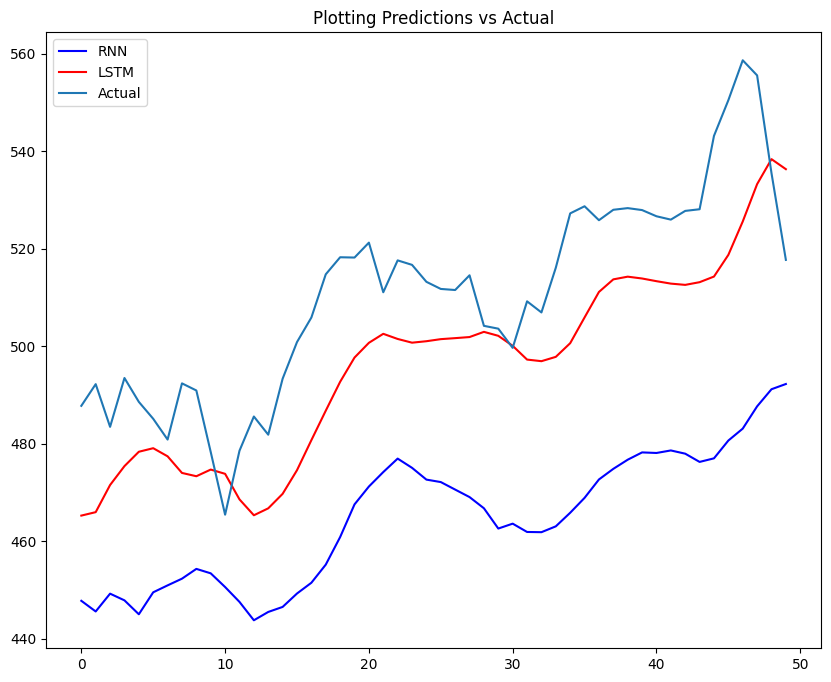

In [27]:
# plotting the predictions and actual data
plt.figure(figsize=(10,8))
plt.plot(rnn_pred, 'b', label='RNN')
plt.plot(lstm_pred, 'r', label='LSTM')
plt.plot(y_test, label='Actual')
plt.title('Plotting Predictions vs Actual')
plt.legend()

As we can see, the lstm prediction is closer to the actual values, albeit a little smoother, whereas the rnn prediction is significantly different.